## Customer Churn Analysis

## Objetivo
Analizar el churn de clientes y su impacto en ingresos.

In [34]:
import pandas as pd

df = pd.read_csv("../data/raw/telco_churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [35]:
df.shape

(7043, 21)

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [37]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [38]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [39]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [40]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [41]:
df = df.dropna()

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

In [43]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

In [44]:
df["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

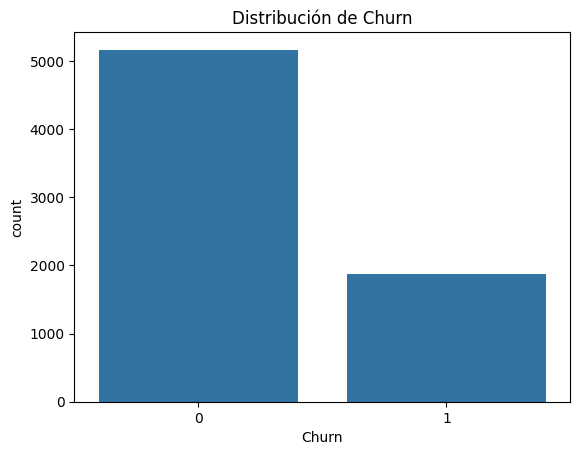

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Churn", data=df)
plt.title("Distribución de Churn")
plt.show()

In [46]:
df["Churn"].value_counts(normalize=True)

Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64

Aproximadamente el 27% de los clientes abandonan el servicio, lo que representa un nivel significativo de churn que impacta directamente en los ingresos.

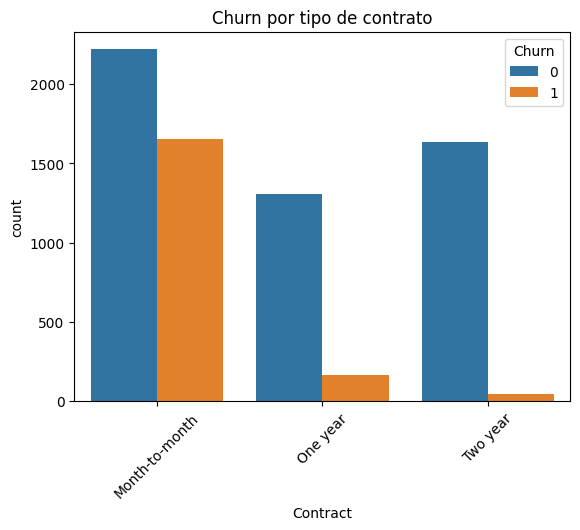

In [47]:
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Churn por tipo de contrato")
plt.xticks(rotation=45)
plt.show()

Los clientes con contrato mensual presentan una tasa de churn significativamente mayor en comparación con los contratos anuales, lo que sugiere menor fidelización en este segmento.

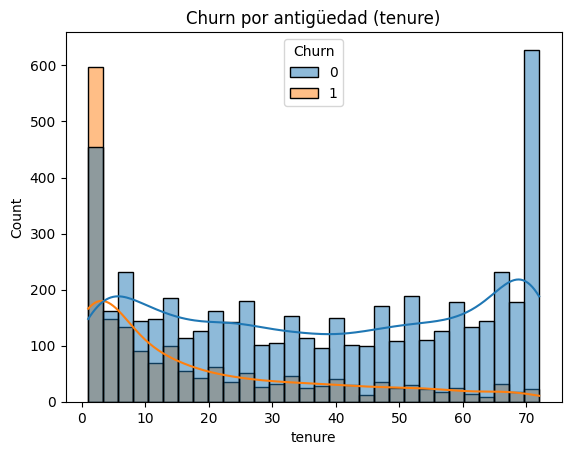

In [48]:
sns.histplot(data=df, x="tenure", hue="Churn", bins=30, kde=True)
plt.title("Churn por antigüedad (tenure)")
plt.show()

Los clientes con menor antigüedad presentan una mayor tasa de churn, lo que indica que el abandono ocurre principalmente en las primeras etapas del ciclo de vida del cliente.

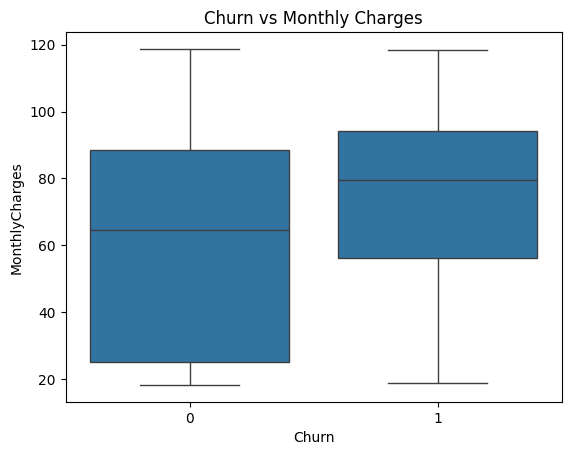

In [49]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Churn vs Monthly Charges")
plt.show()

Los clientes con mayores cargos mensuales tienden a presentar una mayor tasa de churn, lo que sugiere que el precio puede ser un factor relevante en la decisión de abandono.

In [50]:
lost_revenue = df[df["Churn"] == 1]["MonthlyCharges"].sum()
total_revenue = df["MonthlyCharges"].sum()

lost_revenue, total_revenue

(np.float64(139130.85), np.float64(455661.0))

El churn representa una pérdida significativa de ingresos mensuales, lo que impacta directamente en la rentabilidad del negocio.

In [51]:
lost_pct = lost_revenue / total_revenue
lost_pct

np.float64(0.30533850823309433)

El churn representa aproximadamente un 30% de los ingresos mensuales, lo que supone un impacto significativo en la rentabilidad del negocio. La reducción del churn podría generar una mejora directa en los ingresos.

In [52]:
df.to_csv("../data/processed/clean_churn_pg.csv", index=False)